In [1]:
import mcmr

/home/azma/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
lib = mcmr.MaterialLibrary()

lib.add_material(
    name="Fe",
    sigma_t=[0.5, 0.2, 0.1],
    sigma_s=[0.3, 0.1, 0.06],
    sigma_f=[0.05, 0.025, 0.0005],
    nu=[2.7, 2.5, 2.3],
)

lib.add_material(
    name="C",
    sigma_t=[0.4, 0.15, 0.08],
    sigma_s=[0.35, 0.12, 0.07],
    sigma_f=[0.01, 0.005, 0.0001],
    nu=[2.7, 2.5, 2.3],
)

lib.add_material(
    name="Pb",
    sigma_t=[0.6, 0.25, 0.12],
    sigma_s=[0.2, 0.05, 0.02],
)

In [3]:
lib.export("group_materials.xml")
lib = mcmr.MaterialLibrary.load("group_materials.xml")

In [4]:
x_world, y_world = 64, 64

x_grid = []
y_grid = []
for i in range(8, 64, 8):
    x_grid.append(i)
    y_grid.append(i)

material_matrix = [["Fe"] * 8 for _ in range(8)]

sources = [[0] * 8 for _ in range(8)]

In [5]:
world = mcmr.World(
    x_world=x_world, y_world=y_world,
    x_grid=x_grid, y_grid=y_grid,
    material_matrix=material_matrix,
    sources=sources,
    bc_top="reflective",
    bc_bot="reflective",
    bc_left="reflective",
    bc_right="reflective",
)

In [6]:
world.add_circles(
    radius_matrix=[[2.5] * 8 for _ in range(8)],
    material_matrix=[["C"] * 8 for _ in range(8)],
    source_matrix=[[1] * 8 for _ in range(8)],
)

In [7]:
world.export("world.xml")

'world.xml'

In [8]:
sim = world.run(N=100000, max_save=10, mode="group", group_materials=lib)

 MCMR Simulation Engine (multi-group)
 Total Particle   : 100000
 Number of Groups : 3
running...
Progress: [100000/100000] (100%) | Fission bank: 0      
 Simulation End in 0.9974 seconds.



In [9]:
sim.export_xml("mg_result.xml")

In [10]:
t = sim.get_tally()
print("Absorpsi per material :", t.absorp_by_material)
print("Transmisi             :", t.transmission)

Absorpsi per material : {'C': 26105, 'Fe': 174227}
Transmisi             : 0


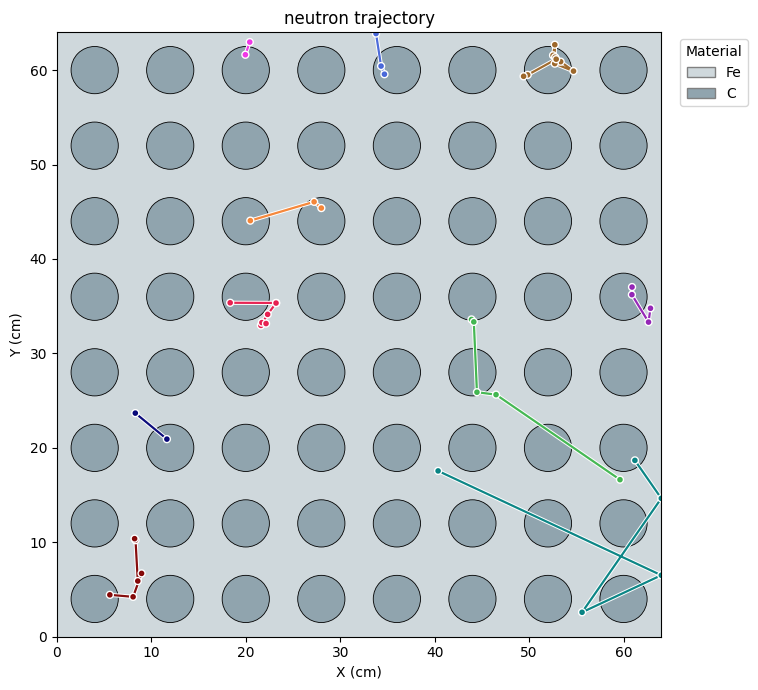

In [11]:
plotter = mcmr.ResultsPlotter("mg_result.xml")
plotter.plot_trajectories(world_xml="world.xml")